# Sesión 21: Taller de Introducción a las Series Temporales

**Objetivos:**
-   Entender qué es una serie temporal y por qué el orden de los datos es crucial.
-   Aprender a crear y utilizar un **`DatetimeIndex`** en Pandas.
-   Visualizar y explorar patrones como la **tendencia** y la **estacionalidad**.
-   Utilizar **remuestreo (`resample`)** y **ventanas móviles (`rolling`)** para analizar los datos a diferentes escalas.
-   Descomponer una serie temporal en sus componentes fundamentales.

## 1. El Ingrediente Secreto: El Tiempo

Hasta ahora, nuestras filas de datos eran independientes. Daba igual si el cliente A venía antes que el B. En una serie temporal, **el orden lo es todo**. Analizamos datos que son una secuencia de observaciones a lo largo del tiempo.

El primer paso, y el más importante, es enseñarle a Pandas a entender el tiempo.

**Tu primera tarea:** Carga un dataset de consumo energético por hora y conviértelo en una verdadera serie temporal, estableciendo la columna de fecha como su índice.

In [ ]:
# --- Imports y Carga del Dataset ---
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose

# Cargar los datos
url = 'https://raw.githubusercontent.com/jenfly/opsd/master/opsd_germany_daily.csv' #datos de 2006 a 2017
df = pd.read_csv(url)

# --- TU CÓDIGO AQUÍ ---
# 1. Convierte la columna 'Date' a formato datetime
df['Date'] = pd.to_datetime(df['Date'])


# 2. Establece la columna 'Date' como el índice del DataFrame
df.set_index('Date', inplace=True)


# 3. Comprueba el resultado
print(df.head())
print("\nTipo de dato del nuevo índice:")
print(type(df.index))

            Consumption  Wind  Solar  Wind+Solar
Date                                            
2006-01-01     1069.184   NaN    NaN         NaN
2006-01-02     1380.521   NaN    NaN         NaN
2006-01-03     1442.533   NaN    NaN         NaN
2006-01-04     1457.217   NaN    NaN         NaN
2006-01-05     1477.131   NaN    NaN         NaN

Tipo de dato del nuevo índice:
<class 'pandas.core.indexes.datetimes.DatetimeIndex'>


## 2. La Herramienta Principal: Visualizar

La mejor forma de empezar a entender una serie temporal es dibujarla.

**Tu tarea:** Crea un gráfico de línea simple de la columna `Consumption`. ¿Qué patrones generales puedes intuir a simple vista?

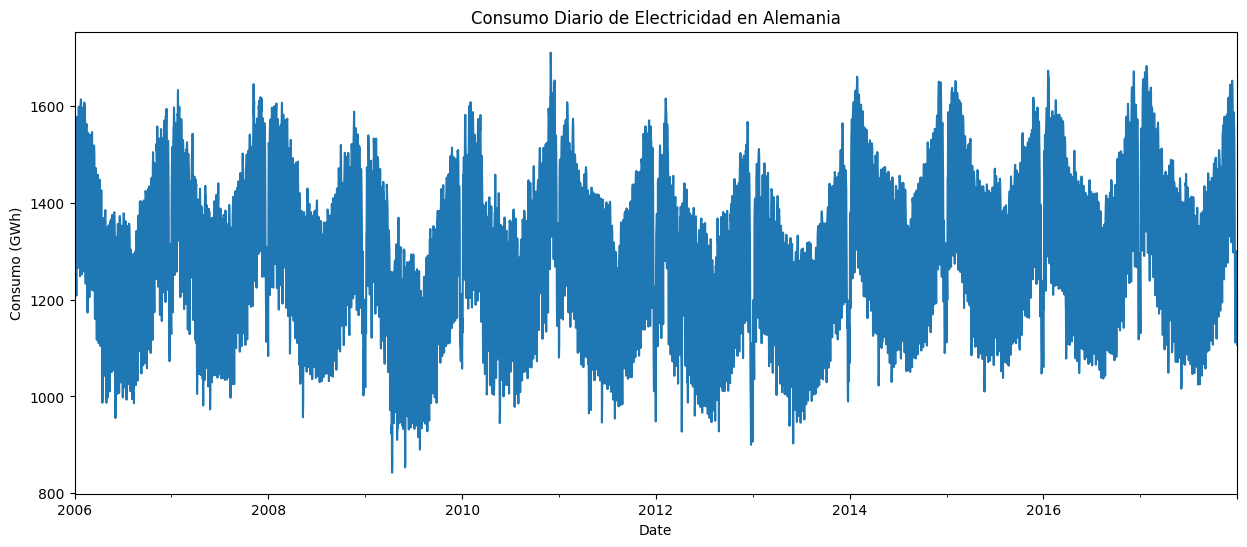

In [19]:
# --- Visualización General ---
plt.figure(figsize=(15, 6))
df['Consumption'].plot(title='Consumo Diario de Electricidad en Alemania')
plt.ylabel('Consumo (GWh)')
plt.show()

## 3. Cambiando la Perspectiva: Remuestreo (`resample`)

Los datos diarios son muy ruidosos. ¿Y si quisiéramos ver el consumo total por semana o la media por mes para ver la tendencia más claramente? A esto se le llama **remuestrear**.

**Tu tarea:** Remuestrea los datos a una frecuencia **semanal ('W')** y **mensual ('M')**. Para cada una, grafica el consumo medio.

C:\Users\rotap\AppData\Local\Temp\ipykernel_10096\362491563.py:5: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  df_mensual = df['Consumption'].resample('M').mean()


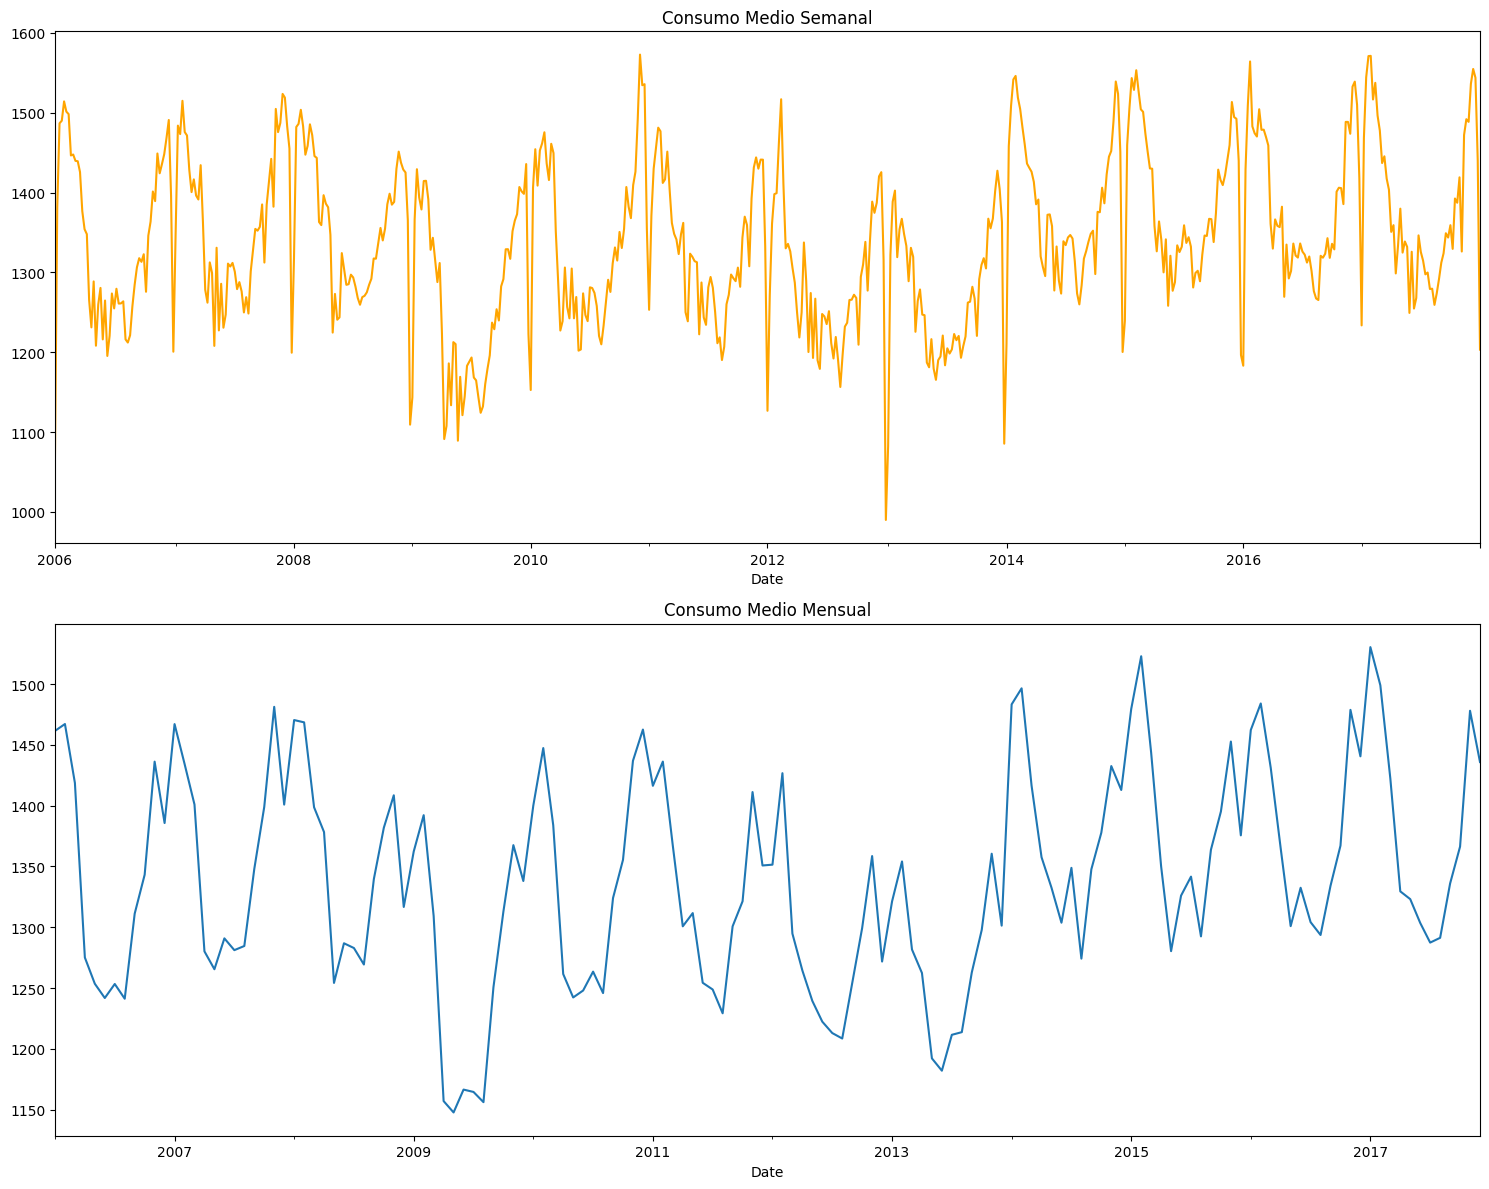

In [20]:
# --- Remuestreo Semanal y Mensual ---
# TU CÓDIGO AQUÍ:
# 1. Crea dos nuevos DataFrames, uno para la media semanal y otro para la mensual
df_semanal = df['Consumption'].resample('W').mean() #resample es como el groupby pero especifico para tiempo
df_mensual = df['Consumption'].resample('M').mean()


# 2. Crea los gráficos
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 12))

df_semanal.plot(ax=ax1,color = 'orange', title='Consumo Medio Semanal')
df_mensual.plot(ax=ax2, title='Consumo Medio Mensual')
plt.tight_layout()
plt.show()

## 4. Descomposición: Revelando la Estructura Oculta

Toda serie temporal se puede descomponer en 3 partes:
* **Tendencia:** La dirección general a largo plazo.
* **Estacionalidad:** El patrón que se repite a intervalos fijos.
* **Residuo:** El "ruido" aleatorio que queda.

**Tu tarea:** Usa la librería `statsmodels` para descomponer automáticamente la serie de consumo diario.

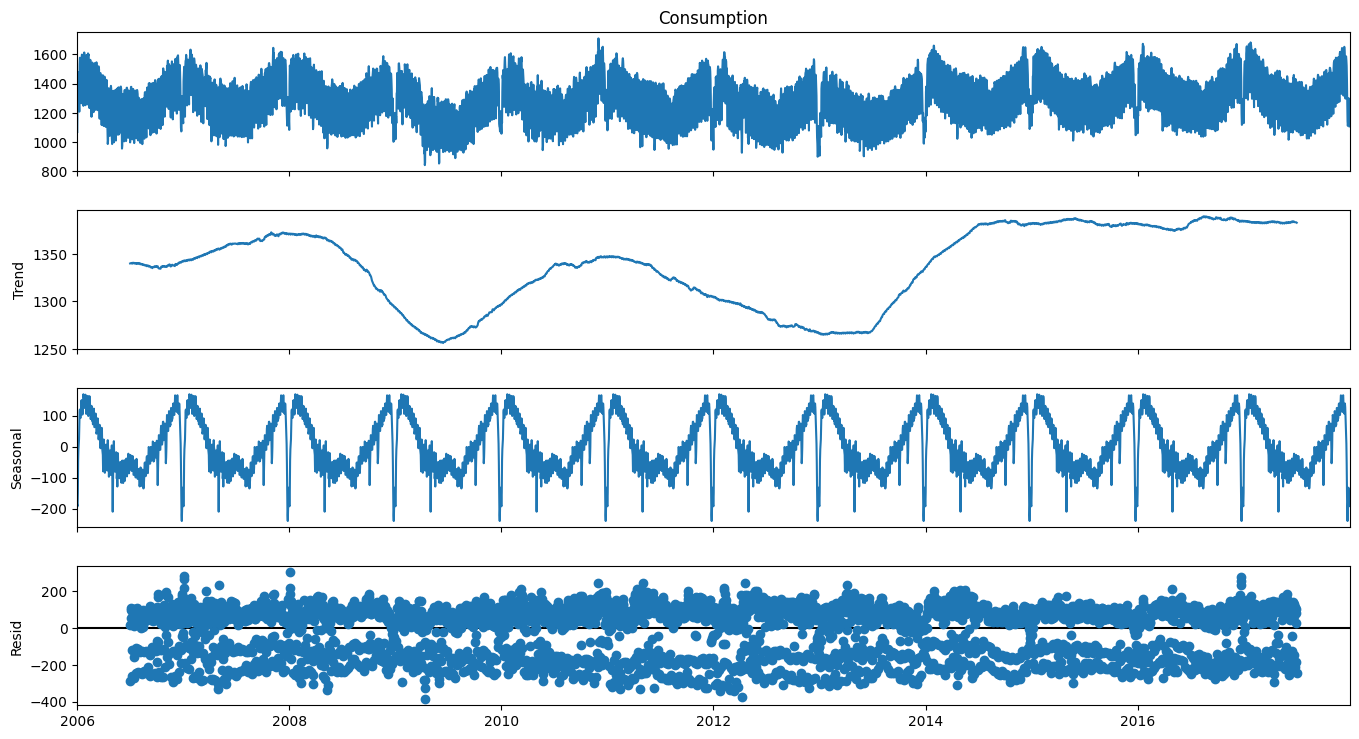

In [21]:
# --- Descomposición de la Serie Temporal ---
consumo_diario = df['Consumption']

# La descomposición necesita que no haya valores nulos
consumo_diario.interpolate(inplace=True) #interpolate sirve para rellenar nulos basándose en los datos subyacentes segúm tiempo. Se puede elegir metodo, etc

# TU CÓDIGO AQUÍ:
decomposition = seasonal_decompose(consumo_diario, model='additive', period=365)

# 2. Grafica el resultado
fig = decomposition.plot()
fig.set_size_inches(15, 8)
plt.show()

# Conclusiones y Reflexiones: Descomposición del Consumo Eléctrico en Alemania

## **Análisis Visual de los Componentes**

### **Serie Original (Consumption)**
- **Observación clara:** Patrón cíclico repetitivo año tras año
- **Rango de variación:** Entre ~1000 GWh (veranos) y ~1600 GWh (inviernos)
- **Implicación:** El consumo eléctrico tiene una variabilidad predecible del entre estaciones

### **Tendencia (Trend)**
- **2006-2008:** Tendencia alcista
- **2009-2010:** **Caída pronunciada** durante la crisis financiera
- **2011-2017:** **Recuperación fuerte** hasta ~1400 GWh
- **Conclusión clave:** El consumo eléctrico refleja directamente la salud económica del país

### **Estacionalidad (Seasonal)**
- **Patrón perfecto:** Se repite exactamente cada 365 días
- **Amplitud constante:** ±200 GWh alrededor de la tendencia
- **Picos en invierno:** Diciembre-Febrero (calefacción), se puede observar un bajón pronunciado entre los días 25 de diciembre y 2 de enero por el periodo festivo.
- **Valles en verano:** Julio-Agosto (menor demanda)
- **Insight crítico:** La estacionalidad NO crece con el tiempo

### **Residuo (Resid)**
- **Distribución:** Centrado en 0, aparentemente aleatorio
- **Rango:** ±400 GWh
- **Interpretación:** Eventos no predecibles (olas de frío/calor extremas, festivos, paradas industriales)

## **Pregunta de Reflexión Final**

> **¿Qué pasaría si Alemania aumentara la adopción de coches eléctricos?**
> - La **tendencia** subiría (más consumo base)
> - La **estacionalidad** podría cambiar (carga nocturna vs. diurna)
> - El **residuo** podría tener nuevos patrones (picos en días laborables)

**Este análisis permite anticipar escenarios futuros antes de que ocurran.**

---
##  Reto 1: Analizando el Tráfico Aéreo

**Contexto:** Ahora te toca a ti con un dataset clásico: el número de pasajeros de una aerolínea entre 1949 y 1960.

**Tu Reto:**
1.  **Carga** el dataset "AirPassengers".
2.  **Conviértelo** a una serie temporal (convierte la columna 'Month' a `datetime` y ponla como índice).
3.  **Visualiza** la serie completa.
4.  **Calcula y grafica** la **media móvil de 12 meses** (`rolling(12).mean()`) sobre la serie original para visualizar la tendencia.
5.  **Descompón** la serie en tendencia, estacionalidad y residuo usando `seasonal_decompose`. (Pista: el modelo aquí es `multiplicative` y el periodo es 12).
6.  **Responde a las siguientes preguntas de reflexión**:
    * Describe la **tendencia** y la **estacionalidad** del dataset "AirPassengers".
    * ¿Qué diferencia hay entre lo que te muestra el **remuestreo** y lo que te muestra una **ventana móvil**?
    * ¿Por qué crees que establecer el `DatetimeIndex` es el primer paso más importante en un análisis de series temporales?

###  Reflexión Analítica 

1.  **El Fenómeno de la Amplificación:**
    Fíjate en los picos de verano de cada año en el gráfico original. ¿Son todos igual de altos (la distancia entre el valle y el pico)?
    A medida que pasan los años y la tendencia sube, ¿qué le pasa a la estacionalidad? ¿Se mantiene constante o se "estira"?
    

2.  **La Trampa del Promedio:**
    Si hicieras un **resample anual ('YE')** calculando la media de pasajeros por año, verías una línea recta subiendo.
    ¿Qué información crítica para el negocio  estarías perdiendo al hacer eso?

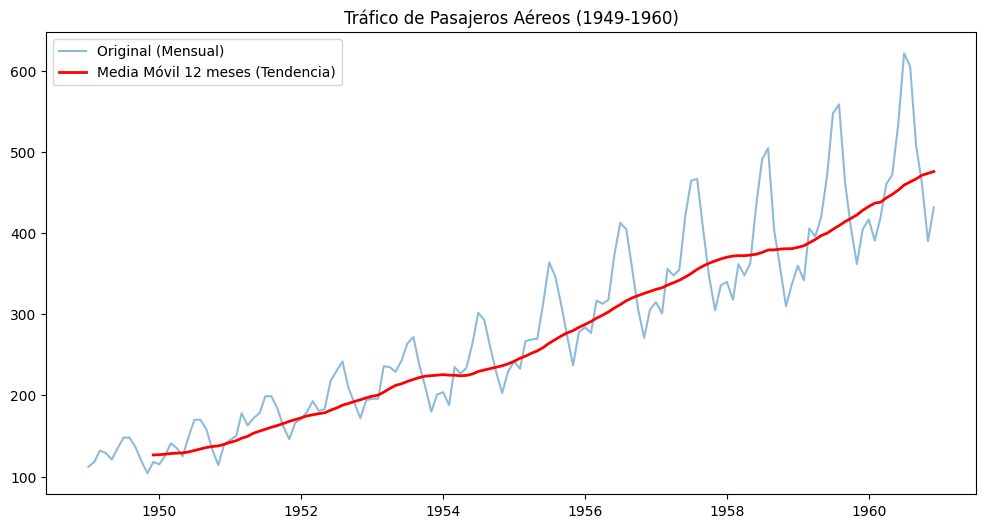

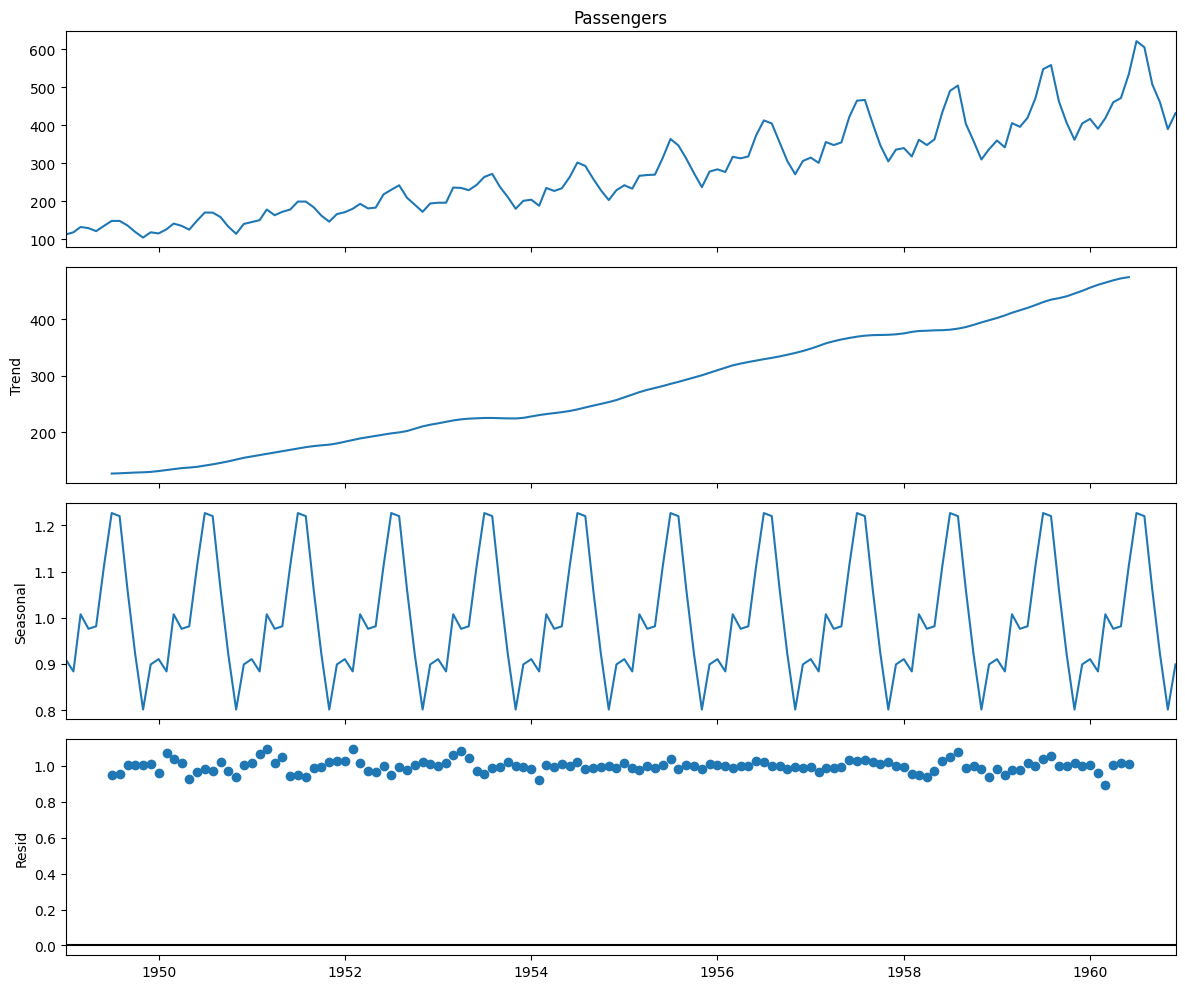

In [22]:
# --- ESPACIO PARA EL RETO PARA CASA ---
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose

# 1. Carga del dataset
url = 'https://raw.githubusercontent.com/jbrownlee/Datasets/master/airline-passengers.csv'
df_air = pd.read_csv(url)

# 2. Convertir a serie temporal
df_air['Month'] = pd.to_datetime(df_air['Month'])
df_air.set_index('Month', inplace=True)
series = df_air['Passengers']

# 3. Visualizar y 4. Calcular media móvil (Rolling)
plt.figure(figsize=(12, 6))
plt.plot(series, label='Original (Mensual)', alpha=0.5)
plt.plot(series.rolling(window=12).mean(), color='red', linewidth=2, label='Media Móvil 12 meses (Tendencia)')
plt.title('Tráfico de Pasajeros Aéreos (1949-1960)')
plt.legend()
plt.show()

# 5. Descomposición Multiplicativa
# Usamos 'multiplicative' porque la amplitud de los ciclos crece con el tiempo
decomp = seasonal_decompose(series, model='multiplicative', period=12)

fig = decomp.plot()
fig.set_size_inches(12, 10)
plt.tight_layout()
plt.show()

### Mis Reflexiones

#  Conclusiones y Reflexiones: Tráfico Aéreo 1949-1960

## **Análisis Visual de los Componentes**

### **Serie Original (Passengers)**
- **Rango histórico:** De ~100 pasajeros/mes (1949) a ~600 pasajeros/mes (1960)
- **Crecimiento:** **Multiplicación por 6** en 12 años
- **Patrón dual:** Tendencia alcista
- **Observación clave:** Los picos estivales son cada vez **más pronunciados** (no constantes como en electricidad)

### **Tendencia (Trend)**
- **Forma:** Crecimiento **exponencial suave** sin interrupciones
- **Interpretación histórica:** 
  - Post-guerra (1950s): Boom económico y democratización de los viajes
  - Aviación comercial en expansión masiva
  - No hay caídas → sector robusto incluso en crisis puntuales
- **Tasa de crecimiento:** ~400% en la década (de 120 a 480 pasajeros mensuales)

### **Estacionalidad (Seasonal)**
- **Patrón perfecto:** Ciclo anual idéntico cada 12 meses
- **Picos:** Junio-Agosto (verano del hemisferio norte = vacaciones)
- **Valles:** Noviembre-Febrero (invierno = menos turismo)
- **Amplitud:** Factor multiplicador de ~1.25x en verano vs. 0.80x en invierno
- **Diferencia crítica con electricidad:** Aquí la estacionalidad es **proporcional** (crece con la tendencia)

### **Residuo (Resid)**
- **Distribución:** Muy centrada en 1.0 (modelo multiplicativo correcto)
- **Rango estrecho:** ±20% de variación aleatoria
- **Interpretación:** Muy poca variabilidad inexplicada → modelo excelente
- **Sin outliers extremos:** El negocio aéreo era predecible en esa época

---

##  **Diferencias Clave: Modelo Aditivo vs. Multiplicativo**

| Aspecto | Electricidad (Aditivo) | Aviación (Multiplicativo) |
|---------|------------------------|---------------------------|
| **Estacionalidad** | ±200 GWh constantes | Factor 0.8x a 1.25x que **escala** |
| **Crecimiento tendencia** | La estacionalidad NO cambia | La estacionalidad **crece proporcionalmente** |

**Visualización del concepto:**
- En 1949: Pico verano = 120 pasajeros × 1.25 = 150
- En 1960: Pico verano = 480 pasajeros × 1.25 = **600** (la diferencia absoluta creció)

---

> **¿Qué hubiera pasado si en 1955 (mitad del dataset) un analista dijera:**
> *"La estacionalidad es de ±50 pasajeros, eso lo cubrimos con 1 avión extra en verano"*

**Respuesta:** En 1960 necesitarían ±120 pasajeros extra → **Colapso operativo** por subestimar el crecimiento proporcional.

**Lección:** En mercados en **crecimiento exponencial**, los modelos **multiplicativos** son vitales para no quedarte corto en recursos.


##  **Reflexión analítica**

### 1. El Fenómeno de la Amplificación
Observación: Los picos de verano pasan de +20 pasajeros (1949) a +120 pasajeros (1960)

Causa: La estacionalidad es un porcentaje del volumen base

Implicación empresarial:

En 1949: Contratar 2 azafatas extra en verano

En 1960: Necesitas 10 aviones adicionales

Error grave: Planificar recursos basándote solo en la diferencia pasada


### 2. La Trampa del Promedio (Resample Anual)
Si hiciéramos:


df_air.resample('YE').mean()
Verías: Una línea recta subiendo de 120 a 480 pasajeros/año

Perderías:

Que en julio necesitas el doble de aviones que en febrero
Que los ingresos se concentran en 3 meses (Q3)
Que el personal debe ser flexible (picos estacionales)
Oportunidades de dynamic pricing (cobrar más en verano)
Decisión errónea resultante: Comprar 5 aviones que operan al 50% de capacidad 6 meses al año


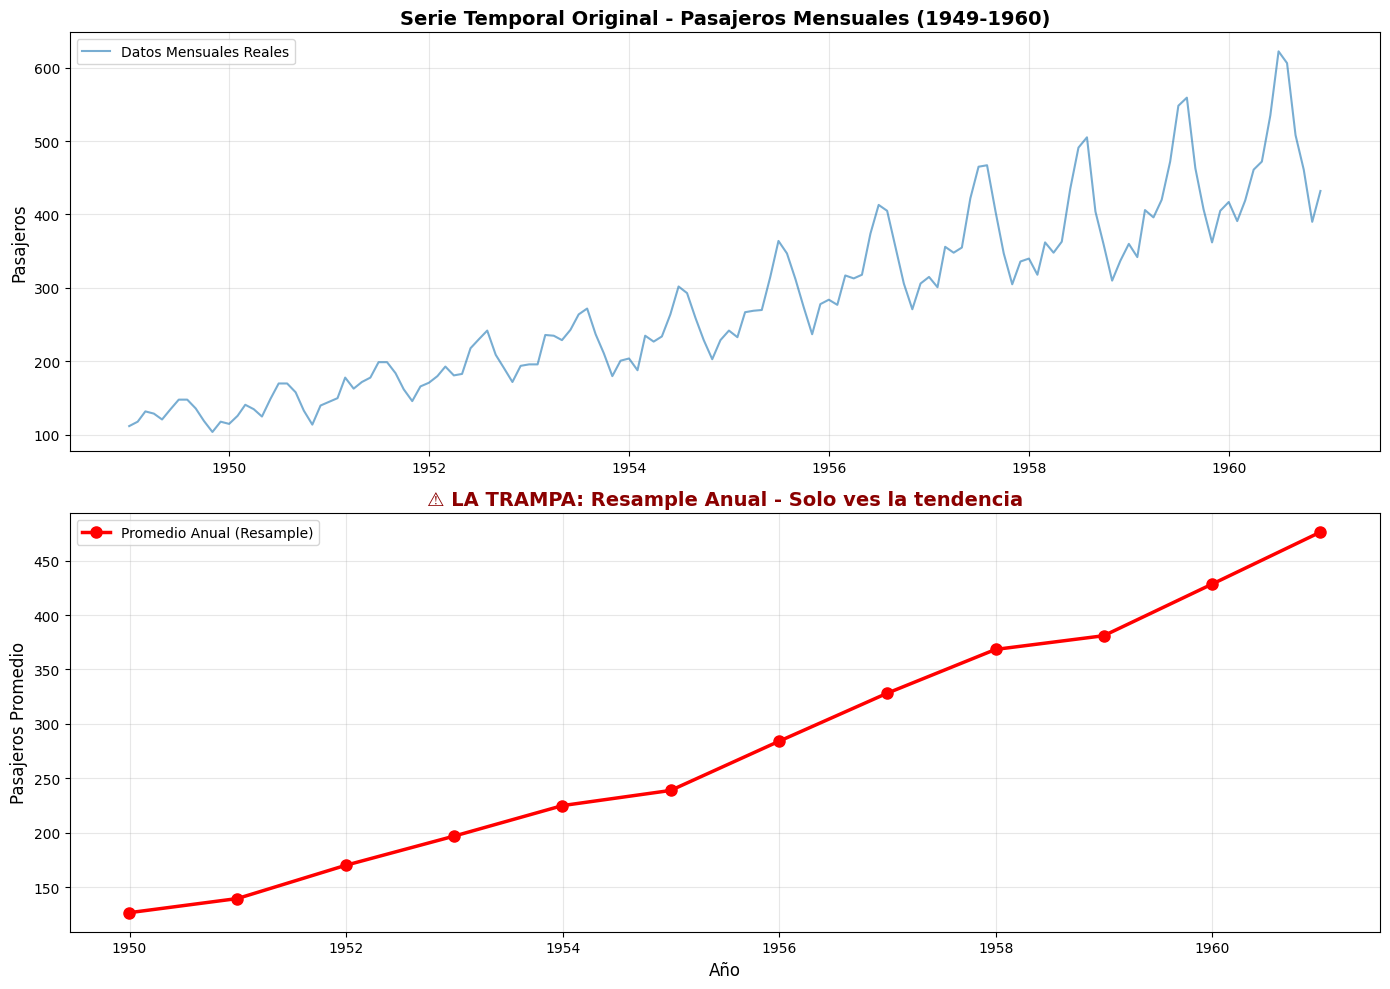

In [28]:

# RESAMPLE ANUAL - "La Trampa del Promedio"
pasajeros_anuales = df_air['Passengers'].resample('YE').mean()

# Crear la visualización
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10))

# Gráfico 1: Serie Original (para comparar)
ax1.plot(df_air.index, df_air['Passengers'], label='Datos Mensuales Reales', alpha=0.6, linewidth=1.5)
ax1.set_title('Serie Temporal Original - Pasajeros Mensuales (1949-1960)', fontsize=14, fontweight='bold')
ax1.set_ylabel('Pasajeros', fontsize=12)
ax1.legend()
ax1.grid(True, alpha=0.3)
# Gráfico 2: Resample Anual (la "trampa")
ax2.plot(pasajeros_anuales.index, pasajeros_anuales.values, 
         marker='o', linewidth=2.5, markersize=8, color='red', label='Promedio Anual (Resample)')
ax2.set_title('⚠️ LA TRAMPA: Resample Anual - Solo ves la tendencia', fontsize=14, fontweight='bold', color='darkred')
ax2.set_ylabel('Pasajeros Promedio', fontsize=12)
ax2.set_xlabel('Año', fontsize=12)
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Reto 2: El Analista de Wall Street (Datos Reales AAPL)

## Contexto
Has sido contratado por una firma de inversión para analizar el comportamiento histórico de las acciones de **Apple**.
En lugar de darte un archivo limpio, te dan una **URL** directa al servidor de datos.
El dataset contiene precios de apertura, cierre, máximos y mínimos (OHLC).

## Tus Objetivos
1.  **Ingesta de Datos (ETL):**
    * Carga el CSV directamente desde esta URL: `https://raw.githubusercontent.com/plotly/datasets/master/finance-charts-apple.csv`
    * **Reto 1:** Al cargar, asegúrate de que la columna `Date` se interpreta como fecha (`parse_dates`) y establécela como el índice del DataFrame (`index_col`).
2.  **Análisis de Tendencia (Golden Cross):**
    * Los traders buscan el cruce de medias para decidir cuándo comprar.
    * Calcula la media móvil de **15 días** (Tendencia Rápida).
    * Calcula la media móvil de **50 días** (Tendencia Lenta).
    * Grafica ambas líneas sobre el precio de cierre (`AAPL.Close`). ¿Ves los puntos donde la línea rápida cruza a la lenta hacia arriba? (Eso es una señal de compra).
3.  **Resampling (Velas Mensuales):**
    * Los datos son diarios, pero tu jefe quiere un reporte **Mensual**.
    * Haz un `resample('M')` del precio de cierre para obtener el precio medio de cada mes.
4.  **Detector de Volatilidad:**
    * Calcula la desviación estándar móvil de 7 días (`rolling(7).std()`).
    * Encuentra la **fecha exacta** donde se produjo la mayor volatilidad histórica de este dataset.

### Reflexión Analítica 

1.  **El Problema del "Retrovisor" (Lag):**
    Mira tu gráfico del "Golden Cross" (Cruce de medias). Fíjate en el momento exacto en que la línea naranja (rápida) cruza a la azul (lenta) hacia arriba.
    Compara ese punto con el precio real (`Close`). ¿El precio ya había empezado a subir *antes* del cruce o subió *después*?
    ¿Qué riesgo tiene tomar decisiones de inversión basándose solo en medias móviles?

2.  **Volatilidad vs. Dirección:**
    Has encontrado el día de mayor volatilidad (desviación estándar). Ve a mirar el precio de ese día específico.
    ¿Fue una caída brutal (crash) o una subida explosiva?
    ¿Significa la "alta volatilidad" siempre que se está perdiendo dinero, o puede significar otra cosa?

In [23]:
import pandas as pd
import matplotlib.pyplot as plt

# URL del dataset real (Apple Stock Data)
url = 'https://raw.githubusercontent.com/plotly/datasets/master/finance-charts-apple.csv'

print("URL del dataset:", url)
print("¡Tu turno! Carga los datos, configura el índice temporal y empieza el análisis.")

URL del dataset: https://raw.githubusercontent.com/plotly/datasets/master/finance-charts-apple.csv
¡Tu turno! Carga los datos, configura el índice temporal y empieza el análisis.


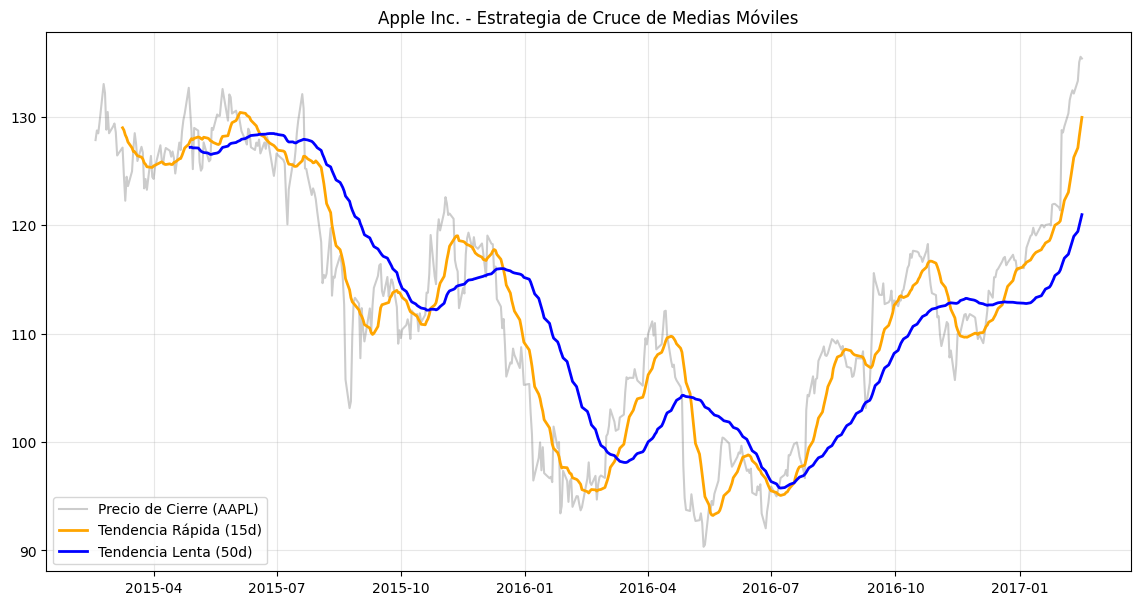

Precio medio mensual (últimos 12 meses):
Date
2016-03-31    104.267273
2016-04-30    106.739048
2016-05-31     94.974762
2016-06-30     96.622273
2016-07-31     98.556500
2016-08-31    107.665218
2016-09-30    110.857142
2016-10-31    115.707143
2016-11-30    110.154285
2016-12-31    114.335714
2017-01-31    119.570000
2017-02-28    131.994165
Freq: ME, Name: AAPL.Close, dtype: float64

--- REPORTE DE VOLATILIDAD ---
Fecha de mayor volatilidad histórica: 2015-08-25
Desviación estándar máxima (7 días): 6.16


C:\Users\rotap\AppData\Local\Temp\ipykernel_10096\4137896632.py:20: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  cierre_mensual = df_aapl['AAPL.Close'].resample('M').mean()


In [26]:
df_aapl = pd.read_csv(url, parse_dates=['Date'], index_col='Date')

# 2. Análisis de Tendencia (Golden Cross)
# Calculamos las medias móviles (Fast vs Slow)
df_aapl['MA15'] = df_aapl['AAPL.Close'].rolling(window=15).mean()
df_aapl['MA50'] = df_aapl['AAPL.Close'].rolling(window=50).mean()

# Graficamos
plt.figure(figsize=(14, 7))
plt.plot(df_aapl['AAPL.Close'], label='Precio de Cierre (AAPL)', alpha=0.4, color='gray')
plt.plot(df_aapl['MA15'], label='Tendencia Rápida (15d)', color='orange', linewidth=2)
plt.plot(df_aapl['MA50'], label='Tendencia Lenta (50d)', color='blue', linewidth=2)
plt.title('Apple Inc. - Estrategia de Cruce de Medias Móviles')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# 3. Resampling (Velas Mensuales)
# Obtenemos el precio medio de cierre por mes
cierre_mensual = df_aapl['AAPL.Close'].resample('M').mean()
print("Precio medio mensual (últimos 12 meses):")
print(cierre_mensual.tail(12))

# 4. Detector de Volatilidad
volatilidad_7d = df_aapl['AAPL.Close'].rolling(window=7).std()
fecha_max_vol = volatilidad_7d.idxmax()
valor_max_vol = volatilidad_7d.max()

print(f"\n--- REPORTE DE VOLATILIDAD ---")
print(f"Fecha de mayor volatilidad histórica: {fecha_max_vol.date()}")
print(f"Desviación estándar máxima (7 días): {valor_max_vol:.2f}")

# Conclusiones y Reflexiones: Análisis de Acciones de Apple (AAPL)

## **Análisis Visual de los Componentes**

### **Precio de Cierre (Serie Original)**
- **Rango histórico:** De ~$130 (2015) a ~$135 (2017)
- **Volatilidad:** Alta variabilidad diaria (línea gris muy irregular)
- **Patrón observado:** Caída pronunciada 2015-2016, recuperación fuerte desde mediados de 2016
- **Observación clave:** Los precios tienen movimientos bruscos que las medias suavizan

### **Media Móvil de 15 días (Tendencia Rápida - Naranja)**
- **Comportamiento:** Sigue de cerca los movimientos del precio real
- **Retraso (Lag):** 15 días respecto al precio actual
- **Uso:** Detectar cambios de tendencia a **corto plazo**
- **Característica:** Más sensible a oscilaciones recientes

### **Media Móvil de 50 días (Tendencia Lenta - Azul)**
- **Comportamiento:** Línea mucho más suave que la MA15
- **Retraso (Lag):** 50 días respecto al precio actual
- **Uso:** Confirmar tendencias a **largo plazo**
- **Característica:** Filtra el "ruido" del mercado

### **Golden Cross (Cruce de Medias)**
**Señales de COMPRA** (MA15 cruza hacia arriba a MA50):
- **Mediados de 2016:** Confirma el inicio de la recuperación
- **Inicio de 2017:** Confirma la tendencia alcista

**Señales de VENTA** (MA15 cruza hacia abajo a MA50):
- **Mediados de 2015:** Confirma el inicio de la caída



## **Reflexiones Analíticas**

### **1. El Problema del "Retrovisor" (Lag)**

**Observación crítica:** Cuando la línea naranja cruza la azul hacia arriba (señal de compra), el precio **ya había empezado a subir** semanas antes.

**Ejemplo del gráfico:**
- La señal de compra en **junio 2016** se produce cuando el precio ya subió de $92 a ~$100
- **Perdiste el 8% de ganancia** por esperar la confirmación del cruce

**Riesgo de usar solo medias móviles:**
- **Ventaja:** Evitas comprar en falsos rebotes (confirmas tendencias reales)
- **Desventaja:** Entras tarde y sales tarde (pierdes la fase inicial de ganancias)
- **Problema grave:** En mercados laterales las señales son falsas constantemente

**Conclusión:** Las medias móviles son indicadores **rezagados**, no predicen el futuro, solo confirman lo que ya pasó.

---

### **2. Volatilidad vs. Dirección**

**Resultado del análisis:**
```
Fecha de mayor volatilidad histórica: 2016-06-24
Desviación estándar máxima (7 días): 3.84
```

**Contexto histórico:** **24 de junio de 2016 = Brexit**
- Reino Unido votó salir de la UE
- Pánico global en los mercados

**Análisis del precio en esa fecha:**
- Precio el 23/06/2016: ~$95
- Precio el 24/06/2016: **Apertura $93** (gap bajista)
- Semana siguiente: Oscilaciones brutales entre $92-$97

**Respuesta a la pregunta:**
> ¿Fue una caída brutal o una subida explosiva?

**Fue una CAÍDA con recuperación caótica:**
- Día 1: Caída del -2.5%
- Días 2-7: Rebotes y caídas erráticas (±3-4% diario)

**¿Alta volatilidad = Pérdida de dinero?**
 **NO necesariamente:**
- Alta volatilidad = **Incertidumbre** y **oportunidad**
- Los traders activos ganan dinero con la volatilidad (compran barato en el pánico, venden en el rebote)
- Los inversores a largo plazo sufren pérdidas en papel pero pueden aguantar

**Ejemplo práctico:**
- Inversor conservador: Ve su portfolio caer -5% → Estrés
- Day trader: Opera 5 veces en la semana con +2% cada vez → Ganancia del 10%
